# Quantum Reachability Analysis - Quickstart

This notebook demonstrates the class-based API for quantum reachability analysis.

**Estimated runtime:** ~7-8 minutes (Cell 2: ~10s, Cells 4-5: ~3-4 min each)

In [18]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from src.models import CanonicalQuditModel, QubitGridModel
from src.criteria import SpectralCriterion, KrylovCriterion, MomentCriterion, Verdict
from src.sampling import DensitySweep, SweepConfig

## Single Reachability Test (~10 seconds)

Test whether a random target state is reachable from |0⟩ using K=10 canonical operators.

In [19]:
model = CanonicalQuditModel(dim=8, seed=42)
submodel = model.sample_submodel(10)
psi = submodel.init_state()
phi = submodel.random_state()

print(f"Model: d={model.dim}, full basis L={model.K}, submodel K={submodel.K}")
print(f"rho = K/d^2 = {submodel.K / model.dim**2:.4f}")
print()

for Criterion in [MomentCriterion, SpectralCriterion, KrylovCriterion]:
    crit = Criterion(submodel, psi, phi, tau=0.99)
    result = crit.is_reachable(maxiter=100, restarts=3)
    print(f"  {Criterion.__name__:20s}: {result.verdict.value}, score={result.score:.4f}")

Model: d=8, full basis L=64, submodel K=10
rho = K/d^2 = 0.1562

  MomentCriterion     : inconclusive, score=0.0000
  SpectralCriterion   : unreachable, score=0.9389
  KrylovCriterion     : unreachable, score=0.8816


## Density Sweep: CanonicalQuditModel (~3-4 min)

Sweep over K values at d=8, 12, 16 to see phase transitions.

In [ ]:
config = SweepConfig(
    n_hamiltonians=30,
    n_targets=15,
    tau=0.99,
    maxiter=150,
    restarts=5,
)

canonical_results = {}
for d in [8, 12, 16]:
    print(f"\nCanonicalQuditModel d={d}")
    model = CanonicalQuditModel(dim=d, seed=42)
    sweep = DensitySweep(model, config)

    # Smart K selection: fewer points, focus on transition
    K_max = min(25, d * d - 1)
    if d == 8:
        K_values = [2, 3, 4, 5, 7, 10, 15, 20, 25]
    elif d == 12:
        K_values = [2, 3, 5, 8, 12, 18, 25]
    else:  # d == 16
        K_values = [2, 3, 5, 8, 12, 18, 25]

    K_values = [k for k in K_values if k <= K_max]
    canonical_results[d] = sweep.run(K_values, criteria=['moment', 'spectral', 'krylov'])

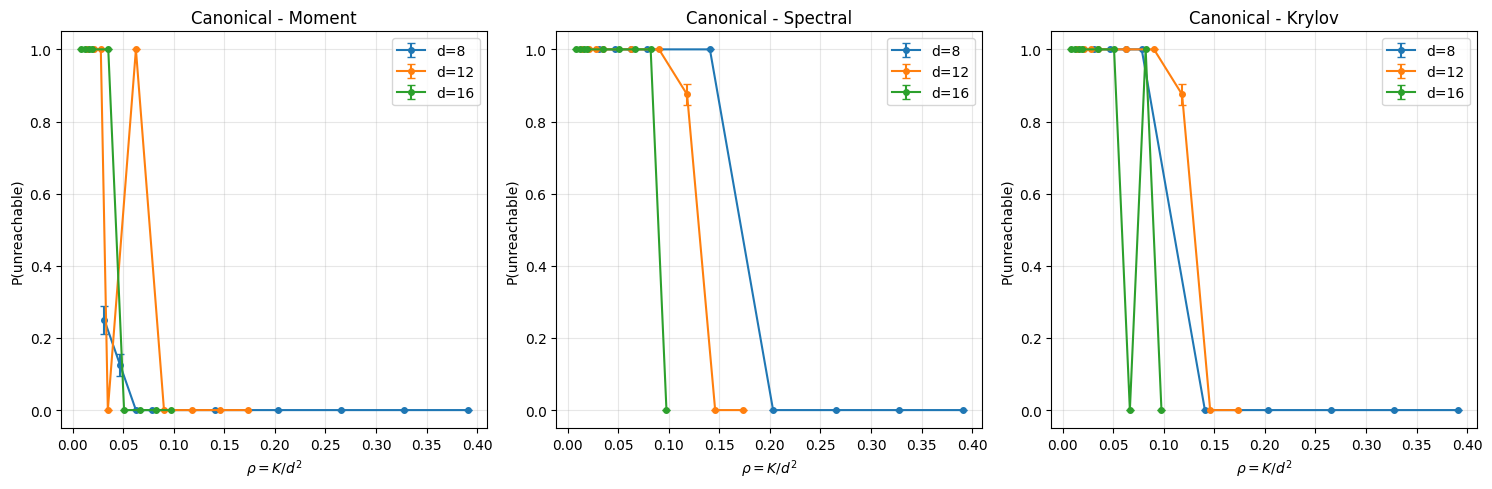

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, crit in zip(axes, ['moment', 'spectral', 'krylov']):
    for d, df in canonical_results.items():
        if len(df) == 0:
            continue
        ax.errorbar(df['rho'], df[f'{crit}_P'], yerr=df[f'{crit}_sem'],
                    fmt='o-', label=f'd={d}', capsize=3, markersize=4)
    ax.set_xlabel(r'$\rho = K/d^2$')
    ax.set_ylabel('P(unreachable)')
    ax.set_title(f'Canonical - {crit.capitalize()}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.savefig('../fig/quickstart_canonical.png', dpi=150, bbox_inches='tight')
plt.show()

## Density Sweep: QubitGridModel (~3-4 min)

Same sweep using geometric two-local Hamiltonians on qubit lattices.

In [ ]:
qubit_results = {}
lattice_configs = {4: (1, 2), 8: (1, 3), 16: (2, 2)}

for d, (nx, ny) in lattice_configs.items():
    print(f"\nQubitGridModel d={d} ({nx}x{ny} lattice)")
    model = QubitGridModel(dim=d, nx=nx, ny=ny, seed=42)
    sweep = DensitySweep(model, config)

    # Smart K selection for QubitGrid
    L = model.K
    if d == 4:
        K_values = [2, 4, 6, 8]
    elif d == 8:
        K_values = [2, 4, 6, 8, 12, 16, 20]
    else:  # d == 16
        K_values = [2, 4, 8, 12, 16, 24, 32]

    K_values = [k for k in K_values if k <= L]
    qubit_results[d] = sweep.run(K_values, criteria=['moment', 'spectral', 'krylov'])

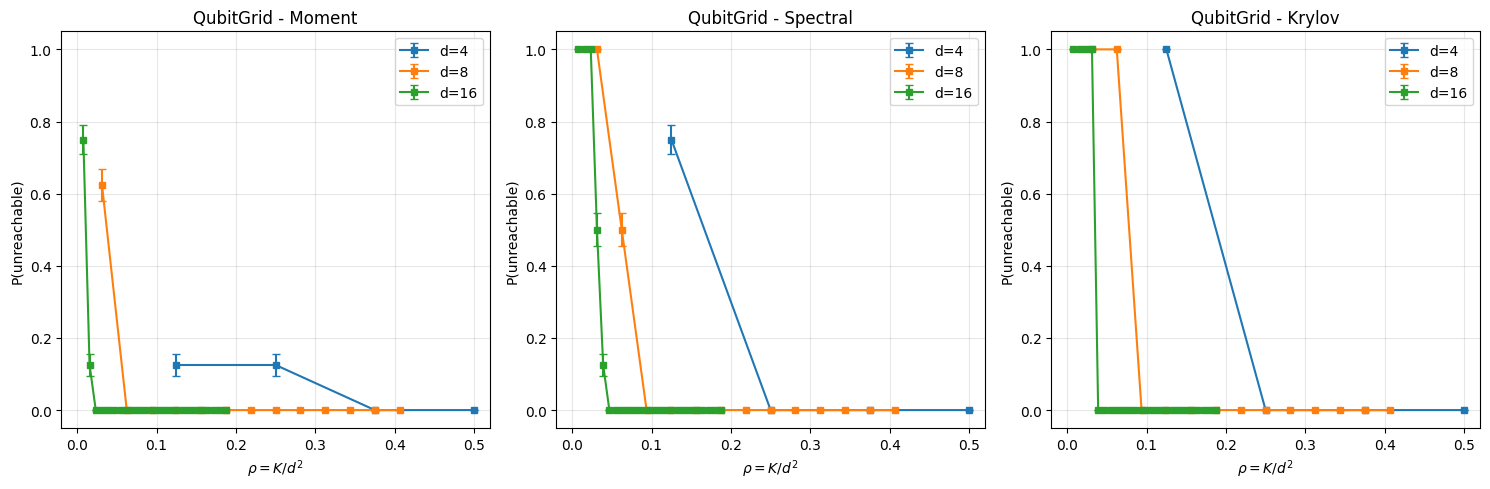

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, crit in zip(axes, ['moment', 'spectral', 'krylov']):
    for d, df in qubit_results.items():
        if len(df) == 0:
            continue
        ax.errorbar(df['rho'], df[f'{crit}_P'], yerr=df[f'{crit}_sem'],
                    fmt='s-', label=f'd={d}', capsize=3, markersize=4)
    ax.set_xlabel(r'$\rho = K/d^2$')
    ax.set_ylabel('P(unreachable)')
    ax.set_title(f'QubitGrid - {crit.capitalize()}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-0.02, 0.52)
plt.tight_layout()
plt.savefig('../fig/quickstart_qubitgrid.png', dpi=150, bbox_inches='tight')
plt.show()